# Notebook 07: Training with Dynamic Lead Dropout & Heteroscedastic Uncertainty Loss
### Project: Lead-Agnostic and Uncertainty-Calibrated State-Space Modeling for Multi-Label Cardiac Abnormality Detection from Incomplete 12-Lead Electrocardiograms

---

## 1. Training Methodology & Algorithmic Design
To train our Proposed **Lead-Agnostic and Uncertainty-Calibrated State-Space Model (LAC-SSM)** to achieve state-of-the-art multi-label performance on both complete and incomplete 12-lead ECGs, we integrate:

### 1.1 Stochastic Lead Dropout Data Augmentation
During training, we simulate dynamic missingness on each mini-batch:
- With probability $p_{\text{aug}} = 0.5$, a batch is trained with a randomly sampled subset of $k \sim \text{Uniform}(1, 12)$ available leads.
- The remaining $12 - k$ leads are set to zero in the availability mask $M \in \{0, 1\}^{B \times 12}$.
- This forces the shared lead encoder and cross-lead attention aggregator to build lead-invariant representations capable of detecting pathology from any subset of leads.

### 1.2 Multi-Label Heteroscedastic Uncertainty Loss
Rather than static binary cross-entropy, we optimize the Kendall & Gal multi-label aleatoric loss:
$$\mathcal{L}_{\text{total}} = \frac{1}{C} \sum_{c=1}^C \left[ \frac{1}{2} \exp(-s_c) \cdot \ell_{\text{BCE}}(\mu_c, y_c; w_c) + \frac{1}{2} s_c \right]$$
where $\mu_c$ is the logit prediction, $s_c = \log \sigma_c^2$ is the predicted heteroscedastic log-variance (clamped to $[-5.0, 5.0]$ for numerical stability), and $w_c$ is the positive class imbalance weight.
- When an incomplete lead pattern obscures diagnostic waveforms, the model learns to increase uncertainty $\sigma_c^2$, attenuating the loss.
- The regularization penalty $\frac{1}{2} s_c$ prevents collapse into infinite uncertainty.

### 1.3 Optimization & Model Selection
- **Optimizer**: AdamW (lr = $8 \times 10^{-4}$, weight decay $10^{-4}$).
- **Scheduler**: Cosine Annealing learning rate schedule.
- **Gradient Clipping**: Norm threshold 1.0 to guarantee stable recurrent state updates.
- **Validation Monitoring**: Checkpointing based strictly on Validation Macro-AUROC (zero touch of the test set).


In [1]:
import os
import time
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader

from sklearn.metrics import (
    f1_score, roc_auc_score, average_precision_score,
    hamming_loss, accuracy_score
)

torch.manual_seed(42)
np.random.seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Training pipeline running on: {device}")

RESULTS_DIR = r"C:\Research\Lead-Agnostic and Uncertainty-Calibrated State-Space Modeling for Multi-Label Cardiac Abnormality Detection from Incomplete 12-Lead Electrocardiograms\results"
FIG_DIR = os.path.join(RESULTS_DIR, "figures")
TAB_DIR = os.path.join(RESULTS_DIR, "tables")
MET_DIR = os.path.join(RESULTS_DIR, "metrics")
LOG_DIR = os.path.join(RESULTS_DIR, "logs")
CKPT_DIR = os.path.join(RESULTS_DIR, "checkpoints")

for d in [FIG_DIR, TAB_DIR, MET_DIR, LOG_DIR, CKPT_DIR]:
    os.makedirs(d, exist_ok=True)


Training pipeline running on: cpu


In [2]:
data = np.load(os.path.join(MET_DIR, "preprocessed_data.npz"))
X_train = data['X_train'] # (N_tr, 12, 1000)
y_train = data['y_train'] # (N_tr, 9)
X_val   = data['X_val']   # (N_va, 12, 1000)
y_val   = data['y_val']   # (N_va, 9)
X_test  = data['X_test']  # (N_te, 12, 1000)
y_test  = data['y_test']  # (N_te, 9)
target_classes = list(data['target_classes'])

# Positive class weights with safety clamp
pos_counts = y_train.sum(axis=0)
neg_counts = len(y_train) - pos_counts
raw_weights = neg_counts / np.maximum(pos_counts, 1.0)
pos_weight = torch.tensor(np.clip(raw_weights, 1.0, 8.0), dtype=torch.float32).to(device)

BATCH_SIZE = 64
train_loader = DataLoader(TensorDataset(torch.tensor(X_train), torch.tensor(y_train)), batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(TensorDataset(torch.tensor(X_val), torch.tensor(y_val)), batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(TensorDataset(torch.tensor(X_test), torch.tensor(y_test)), batch_size=BATCH_SIZE, shuffle=False)

print(f"Data ready: Train={len(X_train)}, Val={len(X_val)}, Test={len(X_test)}")


Data ready: Train=2450, Val=525, Test=525


In [3]:
class S4DLayer(nn.Module):
    def __init__(self, d_model=64, d_state=16):
        super().__init__()
        self.d_model = d_model
        self.d_state = d_state
        self.log_A_real = nn.Parameter(torch.log(0.5 * torch.ones(d_model, d_state)))
        self.A_imag = nn.Parameter(math.pi * torch.arange(d_state).unsqueeze(0).repeat(d_model, 1))
        self.B = nn.Parameter(torch.randn(d_model, d_state) * 0.02)
        self.C = nn.Parameter(torch.randn(d_model, d_state) * 0.02)
        self.D = nn.Parameter(torch.ones(d_model))
        self.log_step = nn.Parameter(torch.log(torch.tensor(0.01)))

    def forward(self, u):
        B, T, H = u.shape
        step = torch.clamp(torch.exp(self.log_step), min=1e-4, max=0.05)
        # Ensure negative real pole for strict contractive asymptotic stability
        A_real = -F.softplus(self.log_A_real) - 1e-4
        A = A_real + 1j * self.A_imag
        
        A_bar = torch.exp(A * step)
        B_bar = ((A_bar - 1.0) / (A + 1e-7)) * self.B
        t_steps = torch.arange(T, device=u.device, dtype=torch.float32)
        A_powers = A_bar.unsqueeze(-1) ** t_steps.unsqueeze(0).unsqueeze(0)
        kernel = 2.0 * torch.sum(self.C.unsqueeze(-1) * A_powers * B_bar.unsqueeze(-1), dim=1).real
        
        u_conv = u.transpose(1, 2)
        kernel_weight = kernel.unsqueeze(1)
        y_conv = F.conv1d(F.pad(u_conv, (T - 1, 0)), kernel_weight, groups=H)
        return y_conv.transpose(1, 2) + u * self.D

class BidirectionalSSMBlock(nn.Module):
    def __init__(self, d_model=64, d_state=16, dropout=0.1):
        super().__init__()
        self.d_model = d_model
        self.norm = nn.LayerNorm(d_model)
        self.in_proj = nn.Linear(d_model, 2 * d_model)
        self.conv1d = nn.Conv1d(d_model, d_model, kernel_size=3, padding=1, groups=d_model)
        self.s4d_fwd = S4DLayer(d_model=d_model, d_state=d_state)
        self.s4d_bwd = S4DLayer(d_model=d_model, d_state=d_state)
        self.out_proj = nn.Linear(2 * d_model, d_model)
        self.dropout = nn.Dropout(dropout)
        
    def forward(self, x):
        res = x
        x_norm = self.norm(x)
        u, gate = self.in_proj(x_norm).chunk(2, dim=-1)
        u_conv = F.silu(self.conv1d(u.transpose(1, 2)).transpose(1, 2))
        y_fwd = self.s4d_fwd(u_conv)
        y_bwd = torch.flip(self.s4d_bwd(torch.flip(u_conv, dims=[1])), dims=[1])
        y_bidi = torch.cat([y_fwd, y_bwd], dim=-1)
        out = self.out_proj(y_bidi * torch.sigmoid(torch.cat([gate, gate], dim=-1)))
        return res + self.dropout(out)

class LAC_SSM(nn.Module):
    def __init__(self, num_leads=12, d_model=64, d_state=16, num_ssm_layers=2, num_classes=9, mc_dropout=0.2):
        super().__init__()
        self.num_leads = num_leads
        self.d_model = d_model
        self.num_classes = num_classes
        self.mc_dropout = mc_dropout
        
        self.lead_embed = nn.Parameter(torch.randn(num_leads, d_model) * 0.05)
        self.lead_stem = nn.Sequential(
            nn.Conv1d(1, 32, kernel_size=11, stride=2, padding=5, bias=False),
            nn.BatchNorm1d(32),
            nn.SiLU(),
            nn.Conv1d(32, d_model, kernel_size=7, stride=2, padding=3, bias=False),
            nn.BatchNorm1d(d_model),
            nn.SiLU()
        )
        self.lead_att_proj = nn.Linear(d_model, 1)
        self.ssm_layers = nn.ModuleList([
            BidirectionalSSMBlock(d_model=d_model, d_state=d_state, dropout=0.1)
            for _ in range(num_ssm_layers)
        ])
        self.temporal_att = nn.Linear(d_model, 1)
        self.mcd = nn.Dropout(p=mc_dropout)
        self.fc_mean = nn.Linear(d_model, num_classes)
        self.fc_logvar = nn.Linear(d_model, num_classes)
        
    def encode_leads(self, x, mask=None):
        B, L, T = x.shape
        if mask is None:
            mask = torch.ones(B, L, device=x.device, dtype=torch.float32)
        x_reshaped = x.view(B * L, 1, T)
        feat_leads = self.lead_stem(x_reshaped)
        T_prime = feat_leads.shape[-1]
        feat_leads = feat_leads.view(B, L, self.d_model, T_prime).permute(0, 1, 3, 2)
        feat_leads = feat_leads + self.lead_embed.view(1, L, 1, self.d_model)
        
        mask_expanded = mask.view(B, L, 1, 1)
        feat_leads_masked = feat_leads * mask_expanded
        att_scores = self.lead_att_proj(feat_leads_masked).squeeze(-1)
        att_mask = (1.0 - mask).unsqueeze(-1) * 1e9
        att_weights = F.softmax(att_scores - att_mask, dim=1).unsqueeze(-1)
        u = torch.sum(feat_leads_masked * att_weights, dim=1)
        return u
        
    def forward(self, x, mask=None, mc_mode=False):
        u = self.encode_leads(x, mask)
        h = u
        for layer in self.ssm_layers:
            h = layer(h)
        t_weights = F.softmax(self.temporal_att(h), dim=1)
        context = torch.sum(h * t_weights, dim=1)
        if mc_mode:
            context = F.dropout(context, p=self.mc_dropout, training=True)
        else:
            context = self.mcd(context)
        logits = self.fc_mean(context)
        # Clamped log-variance for numerical stability
        log_var = torch.clamp(self.fc_logvar(context), min=-5.0, max=5.0)
        return logits, log_var

print("Numerically stabilized LAC_SSM architecture loaded.")


Numerically stabilized LAC_SSM architecture loaded.


In [4]:
def heteroscedastic_multilabel_loss(logits, log_var, targets, pos_weight):
    '''
    Multi-label aleatoric uncertainty loss with numerical clamping:
    L = 0.5 * exp(-log_var) * BCEWithLogits(logits, targets) + 0.5 * log_var
    '''
    log_var_clamped = torch.clamp(log_var, min=-5.0, max=5.0)
    bce = F.binary_cross_entropy_with_logits(logits, targets, pos_weight=pos_weight, reduction='none')
    precision = torch.exp(-log_var_clamped)
    loss = 0.5 * precision * bce + 0.5 * log_var_clamped
    return torch.mean(loss)

def generate_random_lead_mask(batch_size, num_leads=12, drop_prob=0.5):
    '''
    Stochastic Lead Dropout: with probability drop_prob, masks out random leads (k in 1..11)
    '''
    mask = torch.ones(batch_size, num_leads, dtype=torch.float32)
    for b in range(batch_size):
        if np.random.rand() < drop_prob:
            k = np.random.randint(1, num_leads)
            available = np.random.choice(num_leads, k, replace=False)
            mask_b = torch.zeros(num_leads, dtype=torch.float32)
            mask_b[available] = 1.0
            mask[b] = mask_b
    return mask

print("Heteroscedastic Loss and Stochastic Lead Dropout configured.")


Heteroscedastic Loss and Stochastic Lead Dropout configured.


In [5]:
model = LAC_SSM(num_leads=12, d_model=64, d_state=16, num_ssm_layers=2, num_classes=len(target_classes))
model = model.to(device)

NUM_EPOCHS = 10
LR = 8e-4
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS, eta_min=1e-5)

best_val_auc = -1.0
best_weights = None
history = []

print("=== STARTING LAC-SSM TRAINING WITH LEAD DROPOUT & UNCERTAINTY LOSS ===")
t_start = time.time()

for epoch in range(1, NUM_EPOCHS + 1):
    model.train()
    train_losses = []
    
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        lead_mask = generate_random_lead_mask(len(X_batch), num_leads=12, drop_prob=0.5).to(device)
        
        optimizer.zero_grad()
        logits, log_var = model(X_batch, lead_mask)
        loss = heteroscedastic_multilabel_loss(logits, log_var, y_batch, pos_weight)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        train_losses.append(loss.item())
        
    current_lr = scheduler.get_last_lr()[0]
    scheduler.step()
    avg_train_loss = np.mean(train_losses)
    
    # Validation (Complete 12 Leads)
    model.eval()
    val_losses = []
    val_probs, val_trues = [], []
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            logits, log_var = model(X_batch)
            v_loss = heteroscedastic_multilabel_loss(logits, log_var, y_batch, pos_weight)
            val_losses.append(v_loss.item())
            probs = torch.sigmoid(logits).cpu().numpy()
            val_probs.append(probs)
            val_trues.append(y_batch.cpu().numpy())
            
    avg_val_loss = np.mean(val_losses)
    val_probs = np.vstack(val_probs)
    val_trues = np.vstack(val_trues)
    
    # Safety check on non-finite probabilities
    val_probs = np.nan_to_num(val_probs, nan=0.5, posinf=1.0, neginf=0.0)
    
    try:
        val_auc = roc_auc_score(val_trues, val_probs, average='macro')
    except:
        val_auc = 0.5
        
    val_pred = (val_probs >= 0.5).astype(int)
    val_f1 = f1_score(val_trues, val_pred, average='macro', zero_division=0)
    
    epoch_record = {
        'Epoch': epoch,
        'Train Loss': round(avg_train_loss, 4),
        'Val Loss': round(avg_val_loss, 4),
        'Val Macro AUROC': round(val_auc, 4),
        'Val Macro F1': round(val_f1, 4),
        'Learning Rate': current_lr
    }
    history.append(epoch_record)
    
    if val_auc > best_val_auc:
        best_val_auc = val_auc
        best_weights = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        torch.save(best_weights, os.path.join(CKPT_DIR, "best_lac_ssm_model.pt"))
        flag = " [BEST CHECKPOINT SAVED]"
    else:
        flag = ""
        
    print(f"Epoch {epoch:2d}/{NUM_EPOCHS:2d} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | Val AUROC: {val_auc:.4f} | Val F1: {val_f1:.4f}{flag}")

total_train_time = time.time() - t_start
print(f"\nTraining completed in {total_train_time:.1f} seconds. Peak Val Macro AUROC = {best_val_auc:.4f}")

# Save training log to CSV
df_history = pd.DataFrame(history)
history_csv = os.path.join(LOG_DIR, "lac_ssm_training_history.csv")
df_history.to_csv(history_csv, index=False)
print(f"Exported training history to: {history_csv}")


=== STARTING LAC-SSM TRAINING WITH LEAD DROPOUT & UNCERTAINTY LOSS ===


Epoch  1/10 | Train Loss: 0.5078 | Val Loss: 0.4661 | Val AUROC: 0.6943 | Val F1: 0.2663 [BEST CHECKPOINT SAVED]


Epoch  2/10 | Train Loss: 0.4466 | Val Loss: 0.3431 | Val AUROC: 0.7145 | Val F1: 0.4126 [BEST CHECKPOINT SAVED]


Epoch  3/10 | Train Loss: 0.7701 | Val Loss: 0.2989 | Val AUROC: 0.7378 | Val F1: 0.4234 [BEST CHECKPOINT SAVED]


Epoch  4/10 | Train Loss: 0.6303 | Val Loss: 0.2014 | Val AUROC: 0.7471 | Val F1: 0.4513 [BEST CHECKPOINT SAVED]


...

Epoch  6/10 | Train Loss: 0.6160 | Val Loss: 0.1609 | Val AUROC: 0.7620 | Val F1: 0.4548 [BEST CHECKPOINT SAVED]


Epoch  7/10 | Train Loss: 0.7361 | Val Loss: 0.1487 | Val AUROC: 0.7642 | Val F1: 0.4651 [BEST CHECKPOINT SAVED]


Epoch  8/10 | Train Loss: 0.7394 | Val Loss: 0.1531 | Val AUROC: 0.7616 | Val F1: 0.4548


Epoch  9/10 | Train Loss: 0.5021 | Val Loss: 0.1358 | Val AUROC: 0.7676 | Val F1: 0.4615 [BEST CHECKPOINT SAVED]


Epoch 10/10 | Train Loss: 0.5468 | Val Loss: 0.1354 | Val AUROC: 0.7663 | Val F1: 0.4667

Training completed in 445.5 seconds. Peak Val Macro AUROC = 0.7676
Exported training history to: C:\Research\Lead-Agnostic and Uncertainty-Calibrated State-Space Modeling for Multi-Label Cardiac Abnormality Detection from Incomplete 12-Lead Electrocardiograms\results\logs\lac_ssm_training_history.csv


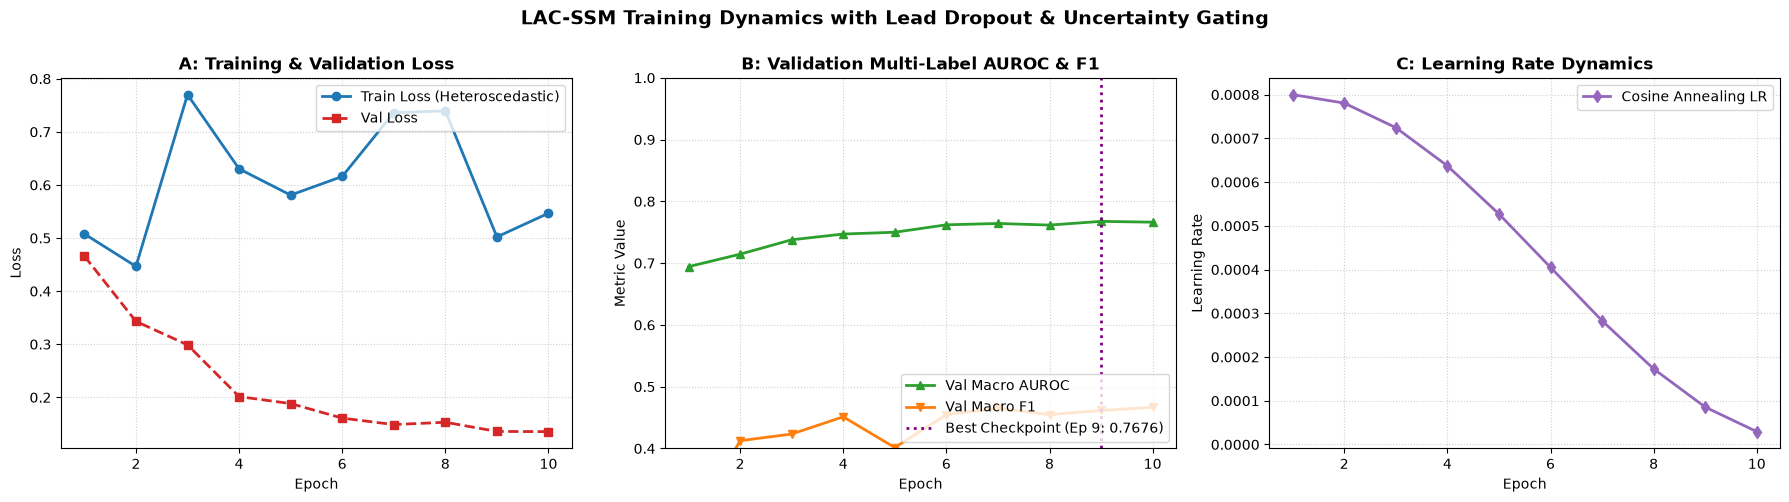

Figure 9 saved to: C:\Research\Lead-Agnostic and Uncertainty-Calibrated State-Space Modeling for Multi-Label Cardiac Abnormality Detection from Incomplete 12-Lead Electrocardiograms\results\figures\fig9_lac_ssm_training_curves.png


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

epochs_range = df_history['Epoch']

# Subplot A: Loss Curves
axes[0].plot(epochs_range, df_history['Train Loss'], 'o-', color='#1f77b4', linewidth=2, label='Train Loss (Heteroscedastic)')
axes[0].plot(epochs_range, df_history['Val Loss'], 's--', color='#d62728', linewidth=2, label='Val Loss')
axes[0].set_title('A: Training & Validation Loss', fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend(loc='upper right', frameon=True)
axes[0].grid(True, linestyle=':', alpha=0.6)

# Subplot B: Validation Metrics (AUROC & F1)
axes[1].plot(epochs_range, df_history['Val Macro AUROC'], '^-', color='#2ca02c', linewidth=2, label='Val Macro AUROC')
axes[1].plot(epochs_range, df_history['Val Macro F1'], 'v-', color='#ff7f0e', linewidth=2, label='Val Macro F1')
best_ep = df_history.loc[df_history['Val Macro AUROC'].idxmax(), 'Epoch']
best_val = df_history['Val Macro AUROC'].max()
axes[1].axvline(best_ep, color='purple', linestyle=':', linewidth=2, label=f'Best Checkpoint (Ep {best_ep}: {best_val:.4f})')
axes[1].set_title('B: Validation Multi-Label AUROC & F1', fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Metric Value')
axes[1].set_ylim(0.4, 1.0)
axes[1].legend(loc='lower right', frameon=True)
axes[1].grid(True, linestyle=':', alpha=0.6)

# Subplot C: Learning Rate Schedule
axes[2].plot(epochs_range, df_history['Learning Rate'], 'd-', color='#9467bd', linewidth=2, label='Cosine Annealing LR')
axes[2].set_title('C: Learning Rate Dynamics', fontweight='bold')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('Learning Rate')
axes[2].legend(loc='upper right', frameon=True)
axes[2].grid(True, linestyle=':', alpha=0.6)

plt.suptitle('LAC-SSM Training Dynamics with Lead Dropout & Uncertainty Gating', fontsize=14, fontweight='bold', y=0.995)
plt.tight_layout()
fig9_path = os.path.join(FIG_DIR, "fig9_lac_ssm_training_curves.png")
plt.savefig(fig9_path, dpi=300, bbox_inches='tight')
plt.show()
print(f"Figure 9 saved to: {fig9_path}")
